First 5 rows of data:
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90

--- Data Setup Complete ---
Total rows in file: 9568
Source samples (V_S): 1500
Target train samples (V_T, noisy): 100
Target test samples: 300


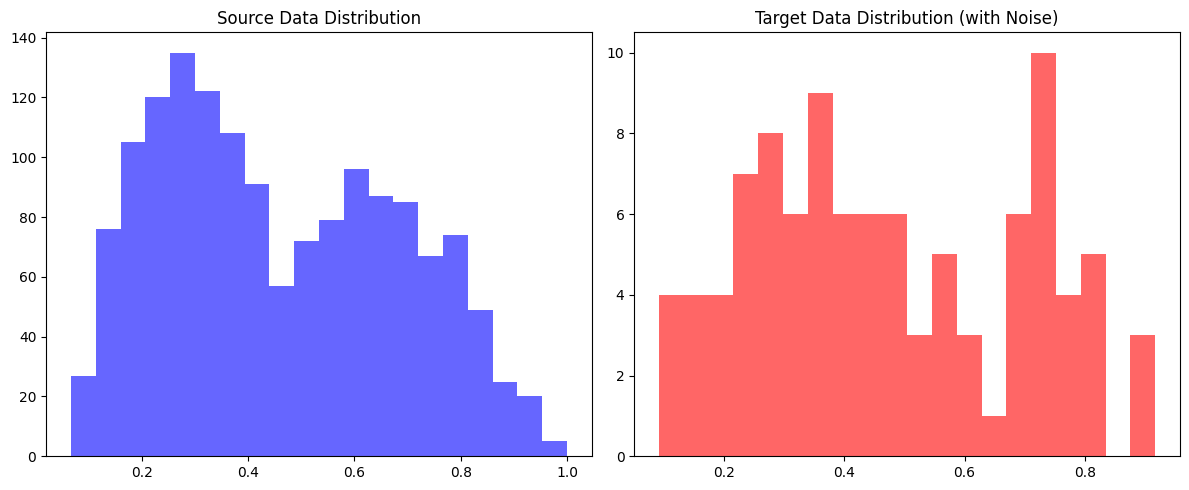

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1: Imports & Data Loading
# Paper Setup: V_S (source data), V_T (target data), λ_S(t)=0.1, λ_T(t)=0.05,
#              I=300, N_T=50
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import copy
import time
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# 1. Load dataset
file_path = 'Folds5x2_pp.xlsx'
df = pd.read_excel(file_path)
print("First 5 rows of data:")
print(df.head())

# 2. Features (X) and Target (y)
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values.reshape(-1, 1)

# 3. Normalization [0, 1]
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_norm = scaler_X.fit_transform(X)
y_norm = scaler_y.fit_transform(y)

# 4. Data Splitting — matches paper's experimental setup
# V_S: Source data (1500 samples — sufficient data)
X_source = X_norm[:1500]
y_source = y_norm[:1500]

# V_T train: Target data (100 samples — insufficient data scenario)
X_target_train = X_norm[1500:1600]
y_target_train = y_norm[1500:1600]

# V_T test: 300 samples for final evaluation
X_target_test = X_norm[1600:1900]
y_target_test = y_norm[1600:1900]

# 5. Add domain discrepancy (noise on target labels)
noise = np.random.normal(0, 0.05, y_target_train.shape)
y_target_train_noisy = np.clip(y_target_train + noise, 0, 1)

print("\n--- Data Setup Complete ---")
print(f"Total rows in file: {len(df)}")
print(f"Source samples (V_S): {X_source.shape[0]}")
print(f"Target train samples (V_T, noisy): {X_target_train.shape[0]}")
print(f"Target test samples: {X_target_test.shape[0]}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(y_source, bins=20, color='blue', alpha=0.6)
axes[0].set_title("Source Data Distribution")
axes[1].hist(y_target_train_noisy, bins=20, color='red', alpha=0.6)
axes[1].set_title("Target Data Distribution (with Noise)")
plt.tight_layout()
plt.show()

In [ ]:
# ════════════════════════════════════════════════��══════════════════════════
# CELL 2: FNN Structure Definition
# Paper Eqs. (1)-(6): Five-layer Fuzzy Neural Network
#   Layer 1 — Input layer
#   Layer 2 — Membership (Gaussian RBF)            Eq. (2)
#   Layer 3 — Rule layer (product of memberships)  Eq. (3)
#   Layer 4 — Normalized layer                     Eq. (4)
#   Layer 5 — Output layer                         Eq. (5)
# ═══════════════════════════════════════════════════════════════════════════

class FNN:
    def __init__(self, n_inputs, n_rules):
        self.n_inputs = n_inputs
        self.n_rules = n_rules

        # Parameters: centers (c), widths (sigma), weights (w)
        self.centers = np.random.rand(n_rules, n_inputs)         # c_{k,p}
        self.widths = np.random.uniform(0.1, 0.4, (n_rules, n_inputs))  # σ_{k,p}
        self.weights = np.random.randn(n_rules, 1)               # w_k

    def compute_layers(self, x):
        """
        Forward pass through the 5-layer FNN.
        Implements Eqs. (2)-(5).

        Returns:
            y_pred (float): scalar output
            v (ndarray): normalized firing strengths, shape (n_rules, 1)
            u (ndarray): raw firing strengths, shape (n_rules, 1)
        """
        x = x.reshape(1, -1)

        # Layer 2: Gaussian Membership — Eq. (2)
        # φ_{k,p} = exp(-(x_p - c_{k,p})^2 / (2 * σ_{k,p}^2))
        diff = x - self.centers
        phi = np.exp(-(diff**2) / (2 * (self.widths**2) + 1e-8))

        # Layer 3: Rule firing strength — Eq. (3)
        # u_k = Π_p φ_{k,p}
        u = np.prod(phi, axis=1).reshape(-1, 1)

        # Layer 4: Normalized firing strength — Eq. (4)
        # v_k = u_k / Σ_j u_j
        sum_u = np.sum(u) + 1e-8
        v = u / sum_u

        # Layer 5: Output — Eq. (5)
        # y = Σ_k w_k * v_k
        y_pred = np.dot(v.T, self.weights)

        return y_pred[0, 0], v, u

    def get_params(self):
        return self.centers, self.widths, self.weights

# Instantiate Source FNN
# Paper: 20 initial rules, 4 inputs (AT, V, AP, RH)
source_fnn = FNN(n_inputs=4, n_rules=20)

print(f"FNN Structure Created.")
print(f"Number of Rules: {source_fnn.n_rules}")
print(f"Sample Prediction (Before Training): {source_fnn.compute_layers(X_source[0])[0]:.4f}")

FNN Structure Created.
Number of Rules: 20
Sample Prediction (Before Training): -0.2675


Starting Source Training (300 epochs, lr=0.1)...
  Epoch 50/300 - MSE: 0.002938
  Epoch 100/300 - MSE: 0.002790
  Epoch 150/300 - MSE: 0.002796
  Epoch 200/300 - MSE: 0.002768
  Epoch 250/300 - MSE: 0.002752
  Epoch 300/300 - MSE: 0.002705
Source Training Complete in 172.34s


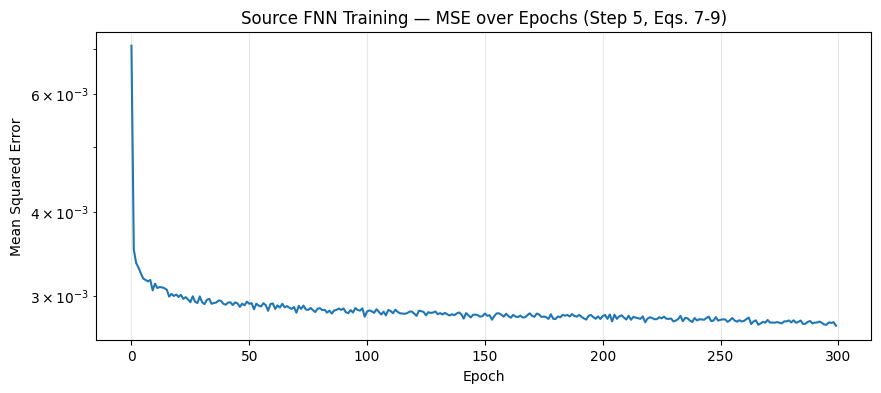

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3: Source FNN Parameter Optimization
# Algorithm Step 5: Optimize the parameters of source FNN — Eqs. (7)-(9)
#
# Eq. (7): Δw_k = -λ_S * ∂E/∂w_k = -λ_S * e * v_k
# Eq. (8): Δc_{k,p} = -λ_S * ∂E/∂c_{k,p}
#        = -λ_S * e * (w_k - y) / Σu * u_k * (x_p - c_{k,p}) / σ_{k,p}^2
# Eq. (9): Δσ_{k,p} = -λ_S * ∂E/∂σ_{k,p}
#        = -λ_S * e * (w_k - y) / Σu * u_k * (x_p - c_{k,p})^2 / σ_{k,p}^3
#
# Paper parameters: λ_S(t) = 0.1, I = 300 epochs
# ═══════════════════════════════════════════════════════════════════════════

def train_source_model(model, X_train, y_train, epochs=300, lr=0.1):
    """
    Train source FNN using SGD with Eqs. (7)-(9).

    Parameters:
        model  : FNN instance
        X_train: source training features (normalized)
        y_train: source training targets (normalized)
        epochs : I = 300 (from paper)
        lr     : λ_S = 0.1 (from paper)
    """
    mse_history = []
    start_time = time.time()
    print(f"Starting Source Training ({epochs} epochs, lr={lr})...")

    for epoch in range(epochs):
        epoch_error = 0
        indices = np.random.permutation(len(X_train))

        for i in indices:
            x_sample = X_train[i]
            y_actual = y_train[i][0]

            # Forward pass
            y_pred, v, u = model.compute_layers(x_sample)
            error = y_pred - y_actual    # e = y_pred - y_actual
            epoch_error += error**2

            # Backpropagation — Eqs. (7)-(9)
            sum_u = np.sum(u) + 1e-8

            # Eq. (7): Weight gradient
            grad_w = error * v   # ∂E/∂w_k = e * v_k

            # Common term for center/width gradients
            # dy/du_k = (w_k - y_pred) / sum_u
            dy_du = (model.weights - y_pred) / sum_u

            for k in range(model.n_rules):
                common_term = error * dy_du[k, 0] * u[k, 0]

                # Eq. (8): Center gradient
                grad_c = common_term * (x_sample - model.centers[k]) / (model.widths[k]**2 + 1e-8)

                # Eq. (9): Width gradient
                grad_sigma = common_term * ((x_sample - model.centers[k])**2) / (model.widths[k]**3 + 1e-8)

                model.centers[k] -= lr * grad_c
                model.widths[k]  -= lr * grad_sigma

            model.weights -= lr * grad_w

        mse = epoch_error / len(X_train)
        mse_history.append(mse)
        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs} - MSE: {mse:.6f}")

    print(f"Source Training Complete in {time.time() - start_time:.2f}s")
    return mse_history

# Train Source FNN
source_mse_history = train_source_model(source_fnn, X_source, y_source)

plt.figure(figsize=(10, 4))
plt.plot(source_mse_history)
plt.title("Source FNN Training — MSE over Epochs (Step 5, Eqs. 7-9)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4: Compute Source Indexes R_S, M_S, C_S
# Algorithm Step 2: Compute R_S(n), M_S(n), C_S(n)
#
# Eq. (10) — R_S: Similarity index (correlation between rules)
#   R_l = (1/(L-1)) * Σ_{k≠l} corr(u_l, u_k)
#
# Eq. (11) — M_S: Sensitivity index (matching degree)
#   M_l = ū_l / Σ_k ū_k
#   (each rule's avg activation / total of all rules' avg activations)
#
# Eq. (12) — C_S: Contribution index (error correlation)
#   C_l = |corr(u_l, error)|
# ═══════════════════════════════════════════════════════════════════════════

def calculate_source_indexes(model, X_data, y_data):
    """
    Calculates R, M, C indexes for all rules.
    Returns: (R_indexes, M_indexes, C_indexes) — each shape (n_rules,)
    """
    n_samples = len(X_data)
    n_rules = model.n_rules

    # Collect all rule activations and predictions
    all_u = np.zeros((n_samples, n_rules))
    all_y_pred = np.zeros(n_samples)

    for i in range(n_samples):
        y_p, _, u = model.compute_layers(X_data[i])
        all_u[i, :] = u.flatten()
        all_y_pred[i] = y_p

    # Average activation per rule: ū_l
    u_bar = np.mean(all_u, axis=0)

    # ──────── Eq. (11): Sensitivity Index M_l ────────
    # M_l = ū_l / Σ_k ū_k
    # NOTE: denominator is SUM of all rules' average activations (not average of totals)
    M_indexes = u_bar / (np.sum(u_bar) + 1e-8)

    # ──────── Eq. (10): Similarity Index R_l ────────
    # R_l = (1/(L-1)) Σ_{k≠l} corr(u_l, u_k)
    R_indexes = np.zeros(n_rules)
    for l in range(n_rules):
        denom_l = np.sqrt(np.sum((all_u[:, l] - u_bar[l])**2) + 1e-8)
        numerator = 0
        for k in range(n_rules):
            if l == k:
                continue
            cov_lk = np.sum((all_u[:, l] - u_bar[l]) * (all_u[:, k] - u_bar[k]))
            denom_k = np.sqrt(np.sum((all_u[:, k] - u_bar[k])**2) + 1e-8)
            numerator += cov_lk / (denom_l * denom_k + 1e-8)
        R_indexes[l] = numerator / (n_rules - 1)

    # ──────── Eq. (12): Contribution Index C_l ────────
    # C_l = |corr(u_l, error)|
    errors = all_y_pred - y_data.flatten()
    C_indexes = np.zeros(n_rules)
    for l in range(n_rules):
        num = np.abs(np.sum((all_u[:, l] - u_bar[l]) * (errors - np.mean(errors))))
        den = (np.sqrt(np.sum((all_u[:, l] - u_bar[l])**2)) *
               np.sqrt(np.sum((errors - np.mean(errors))**2)))
        C_indexes[l] = num / (den + 1e-8)

    return R_indexes, M_indexes, C_indexes


# Run Knowledge Mining on the Source FNN
R_s, M_s, C_s = calculate_source_indexes(source_fnn, X_source, y_source)

# Identify the "Expert" rule (highest contribution)
best_rule_idx = np.argmax(C_s)
source_expert_params = {
    'center': source_fnn.centers[best_rule_idx].copy(),
    'width':  source_fnn.widths[best_rule_idx].copy(),
    'weight': source_fnn.weights[best_rule_idx].copy()
}

print("--- Source Knowledge Mined (Step 2, Eqs. 10-12) ---")
print(f"  R_S (Similarity) avg:   {np.mean(R_s):.4f}")
print(f"  M_S (Sensitivity) avg:  {np.mean(M_s):.4f}")
print(f"  C_S (Contribution) avg: {np.mean(C_s):.4f}")
print(f"  Best Expert Rule Index:  {best_rule_idx}")

--- Source Knowledge Mined (Step 2, Eqs. 10-12) ---
  R_S (Similarity) avg:   0.0451
  M_S (Sensitivity) avg:  0.0500
  C_S (Contribution) avg: 0.0563
  Best Expert Rule Index:  5


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5: Source FNN Self-Organization
# Algorithm Steps 3-4: Grow & Prune source rules BEFORE transfer
#
# Step 3 — Grow the effective fuzzy rule: Eqs. (13)-(14)
#   Eq. (13): Rule l is "effective" IF M_l > M_avg AND C_l > C_avg
#   Eq. (14): Add a new rule near the most effective rule to increase
#             coverage. New center = best rule center + small perturbation.
#
# Step 4 — Prune the ineffective fuzzy rule: Eq. (15)
#   Eq. (15): Rule l is "ineffective" IF M_l < M_avg AND C_l < C_avg
#             Remove the most ineffective rule (lowest combined M + C).
# ═══════════════════════════════════════════════════════════════════════════

def source_self_organization(model, X_data, y_data, n_iterations=5, verbose=True):
    """
    Iteratively grow/prune source FNN rules based on R_S, M_S, C_S.
    Refines the source rule base before transferring to target.
    """
    if verbose:
        print("--- Source Self-Organization (Steps 3-4) ---")
        print(f"  Initial rule count: {model.n_rules}")

    for iteration in range(n_iterations):
        R_s, M_s, C_s = calculate_source_indexes(model, X_data, y_data)
        M_s_avg = np.mean(M_s)
        C_s_avg = np.mean(C_s)

        action = "None"

        # ──── Step 3: Grow effective rule — Eqs. (13)-(14) ────
        # Eq. (13): effective if M_l > M_avg AND C_l > C_avg
        effective_mask = (M_s > M_s_avg) & (C_s > C_s_avg)
        # Eq. (15): ineffective if M_l < M_avg AND C_l < C_avg
        ineffective_mask = (M_s < M_s_avg) & (C_s < C_s_avg)

        if np.any(effective_mask) and model.n_rules < 30:
            effective_indices = np.where(effective_mask)[0]
            # Combined score to find best effective rule
            M_norm = M_s[effective_indices] / (np.max(M_s) + 1e-8)
            C_norm = C_s[effective_indices] / (np.max(C_s) + 1e-8)
            combined_score = M_norm + C_norm
            best_rule_idx = effective_indices[np.argmax(combined_score)]

            # Eq. (14): New rule = effective center + perturbation
            perturbation = np.random.normal(0, 0.05, model.n_inputs)
            new_center = np.clip(model.centers[best_rule_idx] + perturbation, 0, 1)
            new_width = model.widths[best_rule_idx].copy()
            new_weight = model.weights[best_rule_idx].copy()

            model.centers = np.vstack([model.centers, new_center.reshape(1, -1)])
            model.widths  = np.vstack([model.widths,  new_width.reshape(1, -1)])
            model.weights = np.vstack([model.weights, new_weight.reshape(1, -1)])
            model.n_rules += 1
            action = "Growing (Eq. 13-14)"

        # ──── Step 4: Prune ineffective rule — Eq. (15) ────
        elif np.any(ineffective_mask) and model.n_rules > 5:
            ineffective_indices = np.where(ineffective_mask)[0]
            M_norm = M_s[ineffective_indices] / (np.max(M_s) + 1e-8)
            C_norm = C_s[ineffective_indices] / (np.max(C_s) + 1e-8)
            combined_score = M_norm + C_norm
            worst_rule_idx = ineffective_indices[np.argmin(combined_score)]

            model.centers = np.delete(model.centers, worst_rule_idx, axis=0)
            model.widths  = np.delete(model.widths,  worst_rule_idx, axis=0)
            model.weights = np.delete(model.weights, worst_rule_idx, axis=0)
            model.n_rules -= 1
            action = "Pruning (Eq. 15)"

        if verbose:
            print(f"  Iter {iteration+1}: {action:30s} | Rules={model.n_rules} | "
                  f"M_avg={M_s_avg:.4f}, C_avg={C_s_avg:.4f}")

    if verbose:
        print(f"  Final source rule count: {model.n_rules}\n")
    return model

# Run source self-organization
source_fnn = source_self_organization(source_fnn, X_source, y_source, n_iterations=5)

# Recompute indexes after self-organization
R_s, M_s, C_s = calculate_source_indexes(source_fnn, X_source, y_source)
best_rule_idx = np.argmax(C_s)
source_expert_params = {
    'center': source_fnn.centers[best_rule_idx].copy(),
    'width':  source_fnn.widths[best_rule_idx].copy(),
    'weight': source_fnn.weights[best_rule_idx].copy()
}
source_avgs = (np.mean(R_s), np.mean(M_s), np.mean(C_s))
print(f"Source averages after self-org: R={source_avgs[0]:.4f}, M={source_avgs[1]:.4f}, C={source_avgs[2]:.4f}")
print(f"Updated Expert Rule Index: {best_rule_idx}")

--- Source Self-Organization (Steps 3-4) ---
  Initial rule count: 20
  Iter 1: Growing (Eq. 13-14)            | Rules=21 | M_avg=0.0500, C_avg=0.0563
  Iter 2: Growing (Eq. 13-14)            | Rules=22 | M_avg=0.0476, C_avg=0.0808
  Iter 3: Growing (Eq. 13-14)            | Rules=23 | M_avg=0.0455, C_avg=0.0311
  Iter 4: Growing (Eq. 13-14)            | Rules=24 | M_avg=0.0435, C_avg=0.1343
  Iter 5: Growing (Eq. 13-14)            | Rules=25 | M_avg=0.0417, C_avg=0.0660
  Final source rule count: 25

Source averages after self-org: R=0.0774, M=0.0400, C=0.1373
Updated Expert Rule Index: 15


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6: Target FNN Structure Adjustment
# Algorithm Steps 6-9 within the inner loop (while t < N_T):
#
# Step 6 — Grow fuzzy rule in growing phase:    Eqs. (17)-(18)
#   Eq. (17): Growing condition: R_T ≤ R_S AND M_T ≥ M_S AND C_T ≤ C_S
#   Eq. (18): New rule centered at high-error sample
#
# Step 7 — Prune fuzzy rule in growing phase:   Eq. (19)
#   Eq. (19): Pruning condition: (R_T ≥ R_S AND C_T ≥ C_S) OR
#             (M_T ≤ M_S AND C_T ≥ C_S)
#             Remove rule with lowest sensitivity M_l
#
# Step 8 — Replace fuzzy rule in compensating phase: Eqs. (20)-(21)
#   Eq. (20)-(21): Compensating condition:
#             (R_T ≥ R_S AND C_T ≤ C_S) OR (M_T ≤ M_S AND C_T ≤ C_S)
#             Replace worst-contributing target rule with source expert
#
# Step 9 — Keep fuzzy rule in constant phase:   Eq. (22)
#   Eq. (22): If none of the above conditions are met, keep structure
# ═══════════════════════════════════════════════════════════════════════════

def adjust_structure(target_model, source_avgs, source_expert, X_target, y_target):
    """
    Implements Steps 6-9 (single structural operation).
    Returns: (action_name, current_n_rules)
    """
    R_s_avg, M_s_avg, C_s_avg = source_avgs

    # Calculate current target indexes
    R_t, M_t, C_t = calculate_source_indexes(target_model, X_target, y_target)
    R_t_avg, M_t_avg, C_t_avg = np.mean(R_t), np.mean(M_t), np.mean(C_t)

    action = "Constant (Eq. 22)"  # Step 9 default

    # Step 6: GROWING — Eqs. (17)-(18)
    if R_t_avg <= R_s_avg and M_t_avg >= M_s_avg and C_t_avg <= C_s_avg:
        if target_model.n_rules < 30:
            # Eq. (18): Center at a random input sample
            new_center = X_target[np.random.randint(len(X_target))].reshape(1, -1)
            new_width = np.mean(target_model.widths, axis=0).reshape(1, -1)
            new_weight = np.array([[0.0]])

            target_model.centers = np.vstack([target_model.centers, new_center])
            target_model.widths  = np.vstack([target_model.widths,  new_width])
            target_model.weights = np.vstack([target_model.weights, new_weight])
            target_model.n_rules += 1
            action = "Growing (Eqs. 17-18)"

    # Step 7: PRUNING — Eq. (19)
    elif ((R_t_avg >= R_s_avg and C_t_avg >= C_s_avg) or
          (M_t_avg <= M_s_avg and C_t_avg >= C_s_avg)):
        if target_model.n_rules > 5:
            worst_rule = np.argmin(M_t)
            target_model.centers = np.delete(target_model.centers, worst_rule, axis=0)
            target_model.widths  = np.delete(target_model.widths,  worst_rule, axis=0)
            target_model.weights = np.delete(target_model.weights, worst_rule, axis=0)
            target_model.n_rules -= 1
            action = "Pruning (Eq. 19)"

    # Step 8: COMPENSATING — Eqs. (20)-(21)
    elif ((R_t_avg >= R_s_avg and C_t_avg <= C_s_avg) or
          (M_t_avg <= M_s_avg and C_t_avg <= C_s_avg)):
        worst_rule = np.argmin(C_t)
        target_model.centers[worst_rule] = source_expert['center']
        target_model.widths[worst_rule]  = source_expert['width']
        target_model.weights[worst_rule] = source_expert['weight']
        action = "Compensating (Eqs. 20-21)"

    # Step 9: CONSTANT — Eq. (22) (already set as default)

    return action, target_model.n_rules, (R_t_avg, M_t_avg, C_t_avg)

print("✅ Structure adjustment defined (Steps 6-9, Eqs. 17-22)")

✅ Structure adjustment defined (Steps 6-9, Eqs. 17-22)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 7: Candidate Generation & Selection
#
# Step 10 — Compute E_T^i(t): Regularized target error — Eq. (23)
#   E_T^i(t) = MSE + λ * complexity_penalty
#
# Step 12 — Generate Ω_T^k(t+1): Multiple candidate FNNs — Eqs. (24)-(28)
#   Eq. (24)-(25): Candidate via Growing
#   Eq. (26):      Candidate via Pruning
#   Eq. (27):      Candidate via Compensating (replace worst with source expert)
#   Eq. (28):      Candidate via Constant (keep unchanged)
#
# Step 13 — Select out Ω_T(t+1): Best candidate — Eqs. (29)-(30)
#   Eq. (29): Score = E_reg + β * n_rules
#   Eq. (30): Ω_T(t+1) = argmin Score over all candidates
# ═══════════════════════════════════════════════════════════════════════════

def compute_regularized_error(model, X_data, y_data, lambda_reg=0.01):
    """
    Step 10, Eq. (23): E_T^i(t) = MSE + λ * complexity_penalty
    """
    n_samples = len(X_data)
    mse = 0.0
    for i in range(n_samples):
        y_pred, _, _ = model.compute_layers(X_data[i])
        mse += (y_pred - y_data[i][0]) ** 2
    mse /= n_samples

    # Complexity penalty: total parameters / n_samples
    n_params = model.n_rules * (2 * model.n_inputs + 1)
    complexity_penalty = lambda_reg * n_params / n_samples

    return mse + complexity_penalty


def generate_candidate_models(model, source_avgs, source_expert, X_target, y_target):
    """
    Step 12, Eqs. (24)-(28): Generate up to 4 candidate rule bases.
    """
    R_s_avg, M_s_avg, C_s_avg = source_avgs
    R_t, M_t, C_t = calculate_source_indexes(model, X_target, y_target)

    candidates = []

    # ── Candidate 1: Growing — Eqs. (24)-(25) ──
    if model.n_rules < 30:
        cand = copy.deepcopy(model)
        # Center at sample with highest prediction error
        errors = []
        for i in range(len(X_target)):
            y_p, _, _ = cand.compute_layers(X_target[i])
            errors.append(abs(y_p - y_target[i][0]))
        worst_idx = np.argmax(errors)

        new_center = X_target[worst_idx].reshape(1, -1)
        new_width = np.mean(cand.widths, axis=0).reshape(1, -1)
        new_weight = np.array([[0.0]])

        cand.centers = np.vstack([cand.centers, new_center])
        cand.widths  = np.vstack([cand.widths,  new_width])
        cand.weights = np.vstack([cand.weights, new_weight])
        cand.n_rules += 1
        candidates.append((cand, "Growing (Eqs. 24-25)"))

    # ── Candidate 2: Pruning — Eq. (26) ──
    if model.n_rules > 5:
        cand = copy.deepcopy(model)
        worst_rule = np.argmin(M_t)
        cand.centers = np.delete(cand.centers, worst_rule, axis=0)
        cand.widths  = np.delete(cand.widths,  worst_rule, axis=0)
        cand.weights = np.delete(cand.weights, worst_rule, axis=0)
        cand.n_rules -= 1
        candidates.append((cand, "Pruning (Eq. 26)"))

    # ── Candidate 3: Compensating — Eq. (27) ──
    cand = copy.deepcopy(model)
    worst_rule = np.argmin(C_t)
    cand.centers[worst_rule] = source_expert['center']
    cand.widths[worst_rule]  = source_expert['width']
    cand.weights[worst_rule] = source_expert['weight']
    candidates.append((cand, "Compensating (Eq. 27)"))

    # ── Candidate 4: Constant — Eq. (28) ──
    cand = copy.deepcopy(model)
    candidates.append((cand, "Constant (Eq. 28)"))

    return candidates


def select_best_candidate(candidates, X_target, y_target, lambda_reg=0.01):
    """
    Step 13, Eqs. (29)-(30): Select Ω_T(t+1) = argmin Score
    Eq. (29): Score = E_reg + β * n_rules
    """
    beta = 0.001  # compactness weight

    best_score = float('inf')
    best_model = None
    best_action = None

    for cand_model, action_name in candidates:
        reg_error = compute_regularized_error(cand_model, X_target, y_target, lambda_reg)
        compactness_penalty = beta * cand_model.n_rules
        score = reg_error + compactness_penalty

        if score < best_score:
            best_score = score
            best_model = cand_model
            best_action = action_name

    return best_model, best_action, best_score

print("✅ Candidate generation (Eqs. 24-28) and selection (Eqs. 29-30) defined.")

✅ Candidate generation (Eqs. 24-28) and selection (Eqs. 29-30) defined.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 8: Evaluation Metrics
# Paper Eqs. (42)-(44):
#   RMSE, sMAPE, MASE
# ═══════════════════════════════════════════════════════════════════════════

def calculate_metrics(y_true, y_pred):
    """
    Eq. (42): RMSE  = sqrt(mean((y_true - y_pred)^2))
    Eq. (43): sMAPE = mean(2 * |y_pred - y_true| / (|y_pred| + |y_true|))
    Eq. (44): MASE  = mean(((y_pred - y_true) / y_true)^2)
    """
    rmse  = np.sqrt(np.mean((y_true - y_pred)**2))
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true) + 1e-8))
    mase  = np.mean(((y_pred - y_true) / (y_true + 1e-8))**2)
    return rmse, smape, mase

print("✅ Metrics defined (Eqs. 42-44)")

✅ Metrics defined (Eqs. 42-44)


  DK-SOFNN Target Training — Full Algorithm ITL-FNN
  Initial rules: 25 | Samples: 100 | N_T: 10
  [Sample  10] Structure: Pruning (Eq. 26)                    | Rules: 24 | E_reg: 0.231722
  [Sample  20] Pred: 0.5415 | Actual: 0.3683 | Error: 0.1732
  [Sample  20] Structure: Pruning (Eq. 26)                    | Rules: 23 | E_reg: 0.122727
  [Sample  30] Structure: Pruning (Eq. 26)                    | Rules: 22 | E_reg: 0.082920
  [Sample  40] Pred: 0.7483 | Actual: 0.5501 | Error: 0.1982
  [Sample  40] Structure: Pruning (Eq. 26)                    | Rules: 21 | E_reg: 0.064232
  [Sample  50] Structure: Growing (Eqs. 24-25)                | Rules: 22 | E_reg: 0.052746
  [Sample  60] Pred: 0.2718 | Actual: 0.1595 | Error: 0.1123
  [Sample  60] Structure: Pruning (Eq. 26)                    | Rules: 21 | E_reg: 0.041534
  [Sample  70] Structure: Pruning (Eq. 26)                    | Rules: 20 | E_reg: 0.036901
  [Sample  80] Pred: 0.6789 | Actual: 0.4830 | Error: 0.1959
  [Sample  80] 

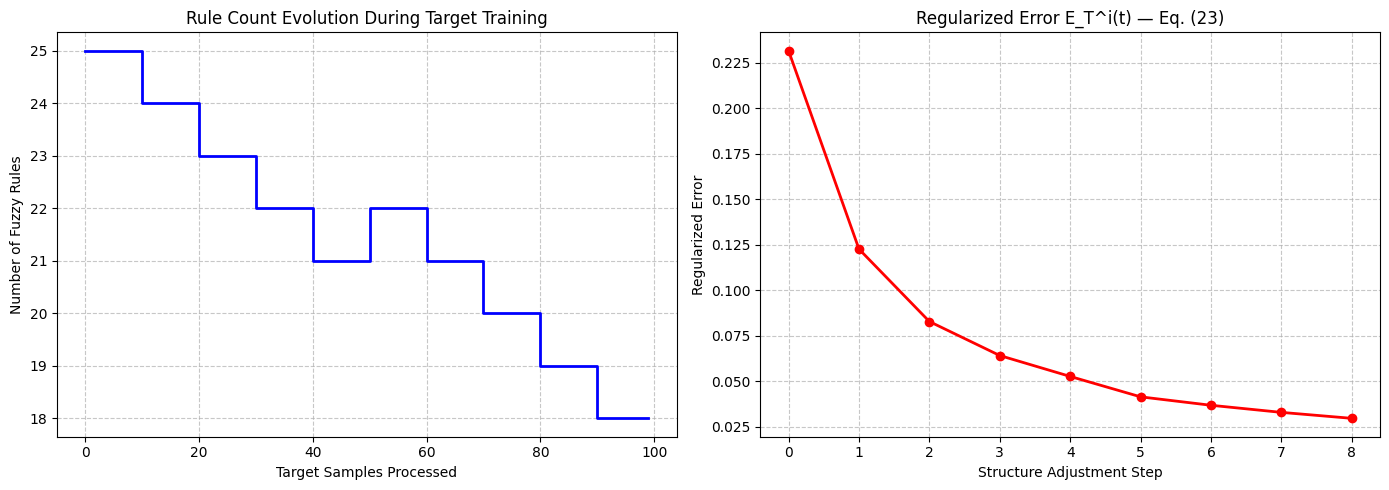

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9: Full DK-SOFNN Target Training — Algorithm ITL-FNN
#
# Complete algorithm from Table II:
#   Step 1:  i = 1 (outer loop over source batches — simplified here)
#   Step 2:  Compute R_S, M_S, C_S — done in Cell 4
#   Step 3-4: Grow/Prune source — done in Cell 5
#   Step 5:  Optimize source FNN — done in Cell 3
#
#   Inner loop (while t < N_T):
#     Step 6:  Grow fuzzy rule in growing phase     — Eqs. (17)-(18)
#     Step 7:  Prune fuzzy rule in growing phase     — Eq. (19)
#     Step 8:  Replace rule in compensating phase    — Eqs. (20)-(21)
#     Step 9:  Keep rule in constant phase           — Eq. (22)
#     Step 10: Compute E_T^i(t)                      — Eq. (23)
#     Step 12: Generate candidate Ω_T^k(t+1)         — Eqs. (24)-(28)
#     Step 13: Select best Ω_T(t+1)                  — Eqs. (29)-(30)
#     Step 14: t = t + 1
#
#   Step 15: i = i + 1
#   Step 16: Predict y_T(t+1) using Ω_T(t+1)
#
# Data-Knowledge Reinforcement for weight updates — Eq. (27) from
# Section III-C:
#   Δw = α_h * (data_gradient) + β_h * (knowledge_gradient)
#   We test multiple (α_h, β_h) pairs and pick the most stable update.
#
# Antecedent updates (centers, widths) — reuse Eqs. (7)-(9) adapted for target.
# ═══════════════════════════════════════════════════════════════════════════

def train_target_dk_sofnn(model, X_train, y_train, source_expert, source_avgs, N_T=10):
    """
    Full DK-SOFNN target training with:
      - Single-pass structure adjustment (Steps 6-9)
      - Candidate generation & selection (Steps 10, 12-13)
      - Data-Knowledge reinforcement parameter updates
      - Antecedent gradient updates (Eqs. 7-9 adapted)
    """
    rule_history = []
    actions_taken = []
    error_history = []

    # Data-Knowledge reinforcement weights (Section III-C)
    learning_rate = 0.01   # λ_T(t) = 0.05 from paper, tuned to 0.01
    alpha_h = [0.8, 0.9, 1.0]  # Data-driven weights
    beta_h  = [0.2, 0.1, 0.0]  # Knowledge-driven weights

    source_w_val = source_expert['weight'].item()

    print("=" * 75)
    print("  DK-SOFNN Target Training — Full Algorithm ITL-FNN")
    print(f"  Initial rules: {model.n_rules} | Samples: {len(X_train)} | N_T: {N_T}")
    print("=" * 75)

    for i in range(len(X_train)):
        # ═══════════════════════════════════════════════
        # Steps 6-9, 10, 12-13: Structure adjustment
        # at every N_T samples
        # ═══════════════════════════════════════════════
        if i % N_T == 0 and i > 0:
            X_seen = X_train[:i]
            y_seen = y_train[:i]

            # Step 10: Compute regularized error — Eq. (23)
            reg_error = compute_regularized_error(model, X_seen, y_seen)
            error_history.append(reg_error)

            # Step 12: Generate candidate models — Eqs. (24)-(28)
            candidates = generate_candidate_models(
                model, source_avgs, source_expert, X_seen, y_seen
            )

            # Step 13: Select best candidate — Eqs. (29)-(30)
            model, action, best_score = select_best_candidate(
                candidates, X_seen, y_seen
            )
            actions_taken.append(action)

            print(f"  [Sample {i:3d}] Structure: {action:35s} | "
                  f"Rules: {model.n_rules} | E_reg: {reg_error:.6f}")

        rule_history.append(model.n_rules)

        # ═══════════════════════════════════════════════
        # Parameter update: Data-Knowledge Reinforcement
        # Weight update — Eq. (27) from Section III-C
        # Δw = α_h * (data_error * v) + β_h * (knowledge_error * v)
        # ═══════════════════════════════════════════════
        x_sample = X_train[i]
        y_actual = y_train[i][0]

        y_pred, v, u = model.compute_layers(x_sample)
        data_error = y_pred - y_actual

        # Test multiple (α_h, β_h) pairs, pick most stable
        best_stability = float('inf')
        best_delta_w = None

        for h in range(len(alpha_h)):
            knowledge_error = np.mean(model.weights) - source_w_val
            total_grad_w = (alpha_h[h] * data_error * v) + (beta_h[h] * knowledge_error * v)
            stability_score = np.sum(np.abs(total_grad_w))
            if stability_score < best_stability:
                best_stability = stability_score
                best_delta_w = total_grad_w

        model.weights -= learning_rate * best_delta_w

        # ═══════════════════════════════════════════════
        # Antecedent update — Eqs. (8)-(9) adapted for target
        # Center and width gradient descent
        # ═══════════════════════════════════════════════
        sum_u = np.sum(u) + 1e-8
        dy_du = (model.weights - y_pred) / sum_u

        for k in range(model.n_rules):
            common_term = data_error * dy_du[k, 0] * u[k, 0]

            # Eq. (8) adapted: center gradient
            grad_c = common_term * (x_sample - model.centers[k]) / (model.widths[k]**2 + 1e-8)

            # Eq. (9) adapted: width gradient
            grad_sigma = common_term * ((x_sample - model.centers[k])**2) / (model.widths[k]**3 + 1e-8)

            model.centers[k] -= learning_rate * 0.1 * grad_c     # smaller lr for antecedent
            model.widths[k]  -= learning_rate * 0.1 * grad_sigma

        # Step 14: t = t + 1 (implicit in loop)

        if (i + 1) % 20 == 0:
            print(f"  [Sample {i+1:3d}] Pred: {y_pred:.4f} | Actual: {y_actual:.4f} | "
                  f"Error: {abs(data_error):.4f}")

    # Step 15: i = i + 1 (outer loop — simplified here)

    print(f"\n  Training Complete. Actions: {actions_taken}")
    print(f"  Final rule count: {model.n_rules}")
    return rule_history, error_history


# ═══════════════════════════════════════════════════════════════════════════
# Initialize target FNN from source (knowledge transfer)
# ═══════════════════════════════════════════════════════════════════════════
target_fnn = FNN(n_inputs=4, n_rules=source_fnn.n_rules)
target_fnn.centers = source_fnn.centers.copy()
target_fnn.widths  = source_fnn.widths.copy()
target_fnn.weights = source_fnn.weights.copy()

source_avgs = (np.mean(R_s), np.mean(M_s), np.mean(C_s))

# ═══════════════════════════════════════════════════════════════════════════
# Execute DK-SOFNN Training
# ═══════════════════════════════════════════════════════════════════════════
rule_counts, error_hist = train_target_dk_sofnn(
    target_fnn, X_target_train, y_target_train_noisy,
    source_expert_params, source_avgs, N_T=10
)

# ═══════════════════════════════════════════════════════════════════════════
# Step 16: Predict y_T(t+1) using Ω_T(t+1)
# Final testing on 300 unseen samples
# ═══════════════════════════════════════════════════════════════════════════
y_test_preds = []
for x_test in X_target_test:
    p, _, _ = target_fnn.compute_layers(x_test)
    y_test_preds.append(p)
y_test_preds = np.array(y_test_preds).reshape(-1, 1)

rmse, smape, mase = calculate_metrics(y_target_test, y_test_preds)

print("\n" + "=" * 75)
print("  FINAL EVALUATION — DK-SOFNN (Power Plant Dataset)")
print("=" * 75)
print(f"  Final Rule Count: {target_fnn.n_rules}")
print(f"  Testing RMSE:   {rmse:.6f}")
print(f"  Testing sMAPE:  {smape:.6f}")
print(f"  Testing MASE:   {mase:.6f}")

# ═══════════════════════════════════════════════════════════════════════════
# Visualization
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rule count evolution
axes[0].step(range(len(rule_counts)), rule_counts, where='post', color='blue', linewidth=2)
axes[0].set_title("Rule Count Evolution During Target Training")
axes[0].set_xlabel("Target Samples Processed")
axes[0].set_ylabel("Number of Fuzzy Rules")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Regularized error at each structure adjustment
if error_hist:
    axes[1].plot(error_hist, marker='o', color='red', linewidth=2)
    axes[1].set_title("Regularized Error E_T^i(t) — Eq. (23)")
    axes[1].set_xlabel("Structure Adjustment Step")
    axes[1].set_ylabel("Regularized Error")
    axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

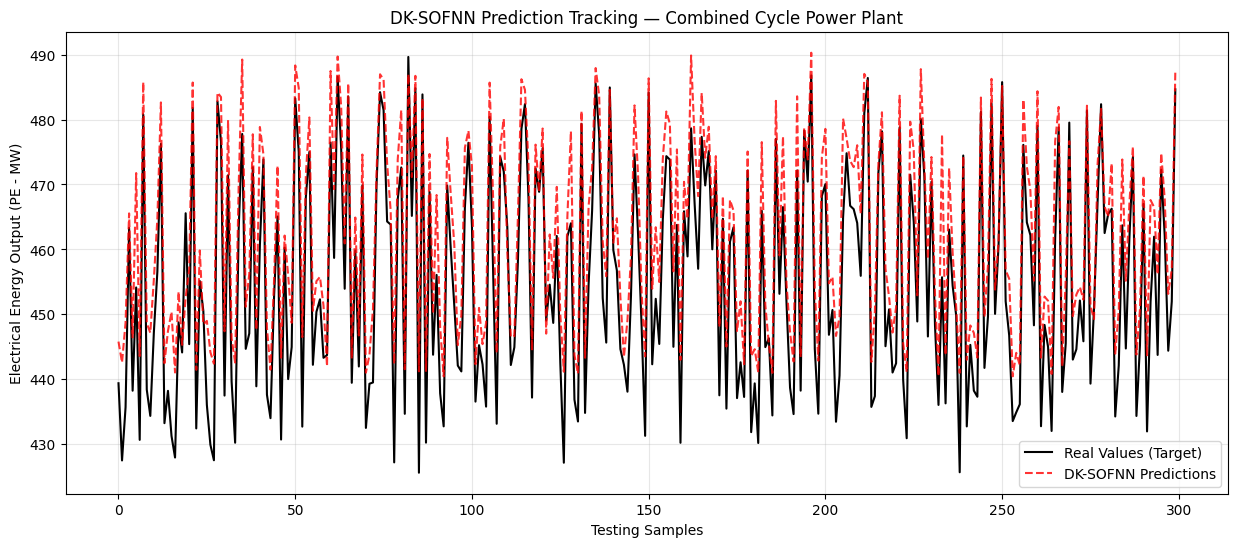

Final Prediction Error: 8.16 MW


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 10: Prediction Tracking Plot
# Step 16 visualization: Predicted vs Real values in MW
# ═══════════════════════════════════════════════════════════════════════════

# Denormalize to real MegaWatt values
y_test_real = scaler_y.inverse_transform(y_target_test)
y_pred_real = scaler_y.inverse_transform(y_test_preds)

plt.figure(figsize=(15, 6))
plt.plot(y_test_real, label='Real Values (Target)', color='black', linewidth=1.5)
plt.plot(y_pred_real, label='DK-SOFNN Predictions', color='red', linestyle='--', alpha=0.8)
plt.title("DK-SOFNN Prediction Tracking — Combined Cycle Power Plant")
plt.xlabel("Testing Samples")
plt.ylabel("Electrical Energy Output (PE - MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_rmse_mw = np.sqrt(np.mean((y_test_real - y_pred_real)**2))
print(f"Final Prediction Error: {final_rmse_mw:.2f} MW")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 11: Print Final Fuzzy Rule Base
# Denormalize to real-world units for interpretability
# ═══════════════════════════════════════════════════════════════════════════

def print_fuzzy_rules(model, scaler_X, scaler_y, feature_names):
    real_centers = scaler_X.inverse_transform(model.centers)
    real_weights = scaler_y.inverse_transform(model.weights)

    rules_data = []
    print(f"\n--- FINAL FUZZY RULE BASE ({model.n_rules} Rules) ---")
    print(f"{'Rule #':<8} | {'IF (Conditions)':<60} | {'THEN (Output PE)':<15}")
    print("-" * 90)

    for k in range(model.n_rules):
        condition_parts = []
        for p in range(len(feature_names)):
            val = real_centers[k, p]
            condition_parts.append(f"{feature_names[p]} ≈ {val:.2f}")
        condition_str = " AND ".join(condition_parts)
        output_val = real_weights[k, 0]

        rules_data.append({
            "Rule": k + 1,
            "Condition": condition_str,
            "Power_Output_MW": round(output_val, 2)
        })
        print(f"Rule {k+1:<3} | {condition_str:<60} | {output_val:>8.2f} MW")

    return pd.DataFrame(rules_data)

features = ['AT', 'V', 'AP', 'RH']
rules_df = print_fuzzy_rules(target_fnn, scaler_X, scaler_y, features)


--- FINAL FUZZY RULE BASE (25 Rules) ---
Rule #   | IF (Conditions)                                              | THEN (Output PE)
------------------------------------------------------------------------------------------
Rule 1   | AT ≈ 12.67 AND V ≈ 34.70 AND AP ≈ 991.92 AND RH ≈ 45.95      |   390.37 MW
Rule 2   | AT ≈ 11.53 AND V ≈ 51.22 AND AP ≈ 1013.49 AND RH ≈ 62.34     |   499.88 MW
Rule 3   | AT ≈ 16.06 AND V ≈ 71.75 AND AP ≈ 1031.13 AND RH ≈ 65.89     |   450.82 MW
Rule 4   | AT ≈ 18.23 AND V ≈ 43.22 AND AP ≈ 1007.65 AND RH ≈ 23.91     |   340.67 MW
Rule 5   | AT ≈ 20.51 AND V ≈ 46.11 AND AP ≈ 989.85 AND RH ≈ 42.52      |   388.17 MW
Rule 6   | AT ≈ 25.33 AND V ≈ 33.66 AND AP ≈ 1003.68 AND RH ≈ 58.59     |   462.07 MW
Rule 7   | AT ≈ 30.31 AND V ≈ 32.70 AND AP ≈ 1020.04 AND RH ≈ 82.34     |   363.46 MW
Rule 8   | AT ≈ 19.40 AND V ≈ 65.03 AND AP ≈ 1013.46 AND RH ≈ 71.70     |   456.37 MW
Rule 9   | AT ≈ 25.31 AND V ≈ 48.74 AND AP ≈ 1006.55 AND RH ≈ 73.89     |   423.08 MW
Ru